# Main Notebook — Run Experiments
This notebook runs PID, LSTM baseline, and Proposed FP-DGL and plots results.


In [5]:
# ===== Fix Python path (add project root) =====
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root added to path:", PROJECT_ROOT)


Project root added to path: e:\PhD\2026 Conf_3\microgrid_forecast_rl_project


In [6]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from data.load_profiles import P1_KW, P2_KW, P3_KW_24, P4_KW_24
from src.microgrid_sim import MicrogridSim
from src.controllers_pid import make_pid_controller
from src.lstm_baseline import train_lstm_forecaster, forecast_next_total_load, make_lstm_baseline_controller
from src.rl_dqn import make_dqn_controller
from src.metrics import compute_metrics


In [7]:
# Confirm load profile peaks
print("Bus3 peak hour:", int(np.argmax(P3_KW_24)), "peak kW:", float(np.max(P3_KW_24)))
print("Bus4 peak hour:", int(np.argmax(P4_KW_24)), "peak kW:", float(np.max(P4_KW_24)))


Bus3 peak hour: 16 peak kW: 33.0
Bus4 peak hour: 20 peak kW: 50.0


In [8]:
# Simulator
sim = MicrogridSim()


In [9]:
# 1) PID baseline
pid = make_pid_controller()
sim_pid = sim.run_day(pid, P1_KW, P2_KW, P3_KW_24, P4_KW_24)


In [10]:
# 2) LSTM baseline (LSTM used ONLY here)
lstm_model, lookback, mode = train_lstm_forecaster(P1_KW, P2_KW, P3_KW_24, P4_KW_24)

def fcast_fn(hour, P3, P4):
    return forecast_next_total_load(hour, P1_KW, P2_KW, P3, P4, lstm_model, lookback)

lstm_ctrl = make_lstm_baseline_controller(sim.S_base_kva)
sim_lstm = sim.run_day(lstm_ctrl, P1_KW, P2_KW, P3_KW_24, P4_KW_24, forecast_fn=fcast_fn)
print("LSTM mode:", mode)


LSTM mode: lstm


In [11]:
import os, numpy as np
os.makedirs("results/loads", exist_ok=True)

np.savez(
    "results/loads/load_profiles_24h.npz",
    P3_KW_24=P3_KW_24,
    P4_KW_24=P4_KW_24
)

print("Load profiles saved.")


Load profiles saved.


In [12]:
# 3) Proposed: Model-Free DQN (no LSTM inside RL)
USE_FORECAST_FEATURE = True
FORECAST_MODE = "next_hour_schedule"

rl_ctrl, rl_logs = make_dqn_controller(
    sim,
    P1_KW, P2_KW, P3_KW_24, P4_KW_24,
    use_forecast_feature=USE_FORECAST_FEATURE,
    forecast_mode=FORECAST_MODE,
    episodes=350
)

sim_rl = sim.run_day(rl_ctrl, P1_KW, P2_KW, P3_KW_24, P4_KW_24)


Episode    5/350 | eps=0.989 | Reward=-189.48 | Mean|V-1|=0.0215
Episode   10/350 | eps=0.975 | Reward=-100.20 | Mean|V-1|=0.0112
Episode   15/350 | eps=0.961 | Reward=-170.18 | Mean|V-1|=0.0193
Episode   20/350 | eps=0.947 | Reward=-161.22 | Mean|V-1|=0.0183
Episode   25/350 | eps=0.933 | Reward=-75.89 | Mean|V-1|=0.0084
Episode   30/350 | eps=0.919 | Reward=-73.17 | Mean|V-1|=0.0081
Episode   35/350 | eps=0.905 | Reward=-151.13 | Mean|V-1|=0.0171
Episode   40/350 | eps=0.890 | Reward=-76.47 | Mean|V-1|=0.0085
Episode   45/350 | eps=0.876 | Reward=-76.07 | Mean|V-1|=0.0084
Episode   50/350 | eps=0.862 | Reward=-72.48 | Mean|V-1|=0.0080
Episode   55/350 | eps=0.848 | Reward=-118.57 | Mean|V-1|=0.0133
Episode   60/350 | eps=0.834 | Reward=-188.83 | Mean|V-1|=0.0215
Episode   65/350 | eps=0.820 | Reward=-57.98 | Mean|V-1|=0.0063
Episode   70/350 | eps=0.806 | Reward=-104.34 | Mean|V-1|=0.0117
Episode   75/350 | eps=0.792 | Reward=-133.41 | Mean|V-1|=0.0151
Episode   80/350 | eps=0.778 | 

In [13]:
# ===== Save RL training logs =====
import os
import numpy as np

os.makedirs("results", exist_ok=True)

np.savez(
    "results/rl_training_logs.npz",
    episode_reward=rl_logs["episode_reward"],
    episode_voltage_deviation=rl_logs["episode_voltage_deviation"],
)

print("RL training logs saved to results/rl_training_logs.npz")


RL training logs saved to results/rl_training_logs.npz


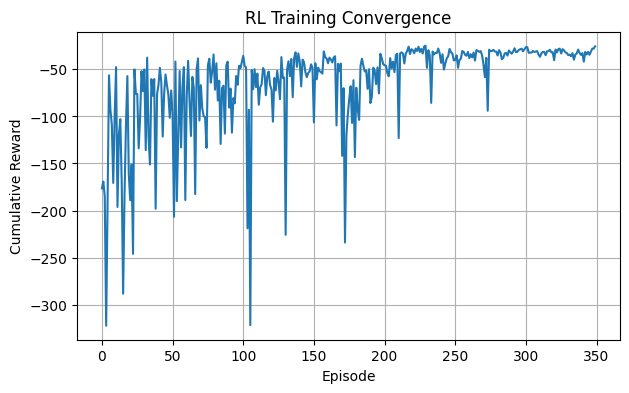

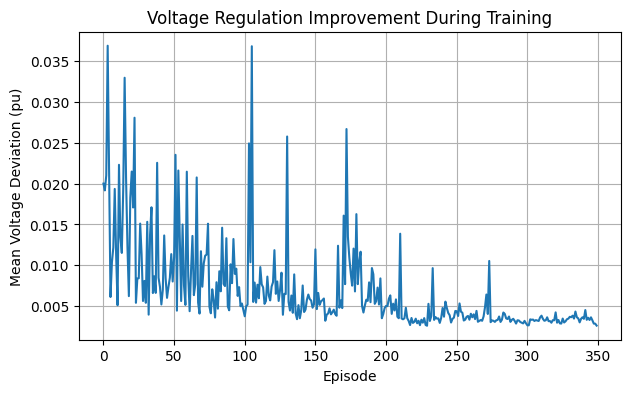

In [14]:
# ===== RL Training Curves =====
plt.figure(figsize=(7,4))
plt.plot(rl_logs["episode_reward"])
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("RL Training Convergence")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(rl_logs["episode_voltage_deviation"])
plt.xlabel("Episode")
plt.ylabel("Mean Voltage Deviation (pu)")
plt.title("Voltage Regulation Improvement During Training")
plt.grid(True)
plt.show()


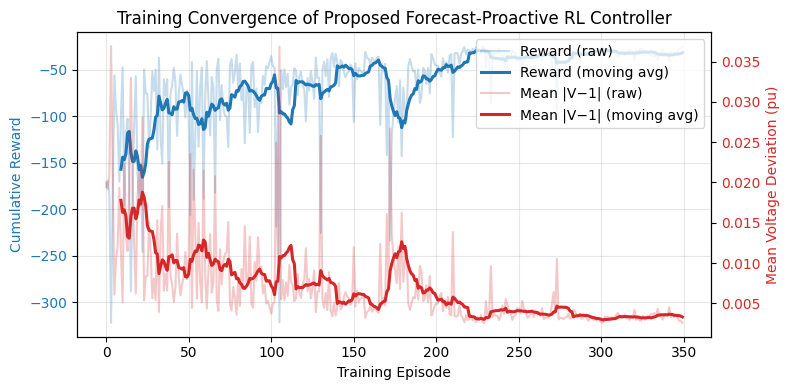

In [15]:
def moving_average(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode="valid")

episodes = np.arange(len(rl_logs["episode_reward"]))

fig, ax1 = plt.subplots(figsize=(8,4))

# ---- Left axis: Reward ----
ax1.plot(
    episodes,
    rl_logs["episode_reward"],
    color="tab:blue",
    alpha=0.25,
    label="Reward (raw)"
)
ax1.plot(
    episodes[9:],
    moving_average(rl_logs["episode_reward"], 10),
    color="tab:blue",
    linewidth=2.2,
    label="Reward (moving avg)"
)
ax1.set_xlabel("Training Episode")
ax1.set_ylabel("Cumulative Reward", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# ---- Right axis: Voltage deviation ----
ax2 = ax1.twinx()
ax2.plot(
    episodes,
    rl_logs["episode_voltage_deviation"],
    color="tab:red",
    alpha=0.25,
    label="Mean |V−1| (raw)"
)
ax2.plot(
    episodes[9:],
    moving_average(rl_logs["episode_voltage_deviation"], 10),
    color="tab:red",
    linewidth=2.2,
    label="Mean |V−1| (moving avg)"
)
ax2.set_ylabel("Mean Voltage Deviation (pu)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# ---- Legends ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.grid(True, alpha=0.3)
plt.title("Training Convergence of Proposed Forecast-Proactive RL Controller")
plt.tight_layout()
plt.show()


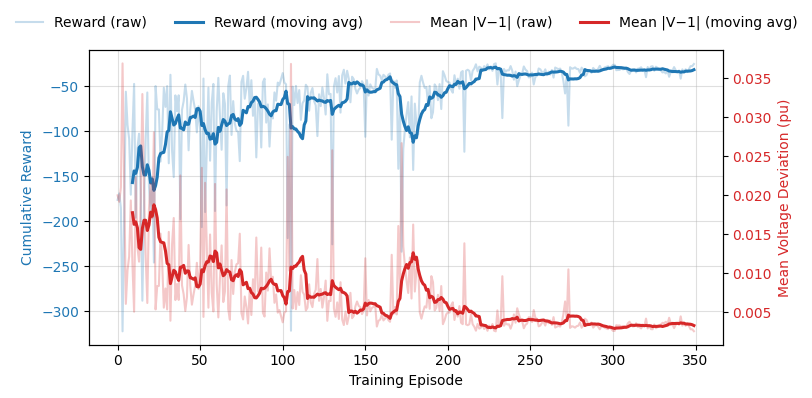

In [24]:
def moving_average(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode="valid")

episodes = np.arange(len(rl_logs["episode_reward"]))

fig, ax1 = plt.subplots(figsize=(8, 4))

# ---- Left axis: Reward ----
ax1.plot(
    episodes,
    rl_logs["episode_reward"],
    color="tab:blue",
    alpha=0.25,
    label="Reward (raw)"
)
ax1.plot(
    episodes[9:],
    moving_average(rl_logs["episode_reward"], 10),
    color="tab:blue",
    linewidth=2.2,
    label="Reward (moving avg)"
)
ax1.set_xlabel("Training Episode")
ax1.set_ylabel("Cumulative Reward", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# ---- Right axis: Voltage deviation ----
ax2 = ax1.twinx()
ax2.plot(
    episodes,
    rl_logs["episode_voltage_deviation"],
    color="tab:red",
    alpha=0.25,
    label="Mean |V−1| (raw)"
)
ax2.plot(
    episodes[9:],
    moving_average(rl_logs["episode_voltage_deviation"], 10),
    color="tab:red",
    linewidth=2.2,
    label="Mean |V−1| (moving avg)"
)
ax2.set_ylabel("Mean Voltage Deviation (pu)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# ---- Horizontal Legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

fig.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    ncol=4,              # horizontal layout
    frameon=False,
    bbox_to_anchor=(0.5, 1)
)

ax1.grid(True, alpha=0.4)
#plt.title("Training Convergence of Proposed Forecast-Proactive RL Controller")
plt.tight_layout(rect=[0, 0, 1, 0.92])

# ---- Save as PDF ----
plt.savefig("RL_Training_Convergence.pdf", format="pdf", bbox_inches="tight")
plt.show()


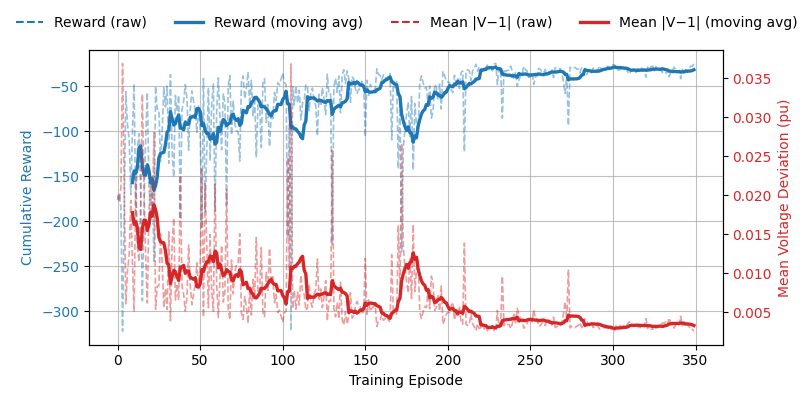

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def moving_average(x, w=10):
    return np.convolve(x, np.ones(w) / w, mode="valid")

episodes = np.arange(len(rl_logs["episode_reward"]))

fig, ax1 = plt.subplots(figsize=(8, 4))

# ---- Left axis: Reward ----
ax1.plot(
    episodes,
    rl_logs["episode_reward"],
    color="tab:blue",
    alpha=0.45,
    linestyle="--",
    linewidth=1.2
)
ax1.plot(
    episodes[9:],
    moving_average(rl_logs["episode_reward"], 10),
    color="tab:blue",
    linewidth=2.4
)
ax1.set_xlabel("Training Episode")
ax1.set_ylabel("Cumulative Reward", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# ---- Right axis: Voltage deviation ----
ax2 = ax1.twinx()
ax2.plot(
    episodes,
    rl_logs["episode_voltage_deviation"],
    color="tab:red",
    alpha=0.45,
    linestyle="--",
    linewidth=1.2
)
ax2.plot(
    episodes[9:],
    moving_average(rl_logs["episode_voltage_deviation"], 10),
    color="tab:red",
    linewidth=2.4
)
ax2.set_ylabel("Mean Voltage Deviation (pu)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# ---- Custom Legend (clear + meaningful) ----
legend_lines = [
    Line2D([0], [0], color="tab:blue", linestyle="--", linewidth=1.5,
           label="Reward (raw)"),
    Line2D([0], [0], color="tab:blue", linestyle="-", linewidth=2.4,
           label="Reward (moving avg)"),
    Line2D([0], [0], color="tab:red", linestyle="--", linewidth=1.5,
           label="Mean |V−1| (raw)"),
    Line2D([0], [0], color="tab:red", linestyle="-", linewidth=2.4,
           label="Mean |V−1| (moving avg)")
]

fig.legend(
    handles=legend_lines,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1)
)

# ---- Styling ----
ax1.grid(True, alpha=0.8)
#plt.title("Training Convergence of Proposed Forecast-Proactive RL Controller")
plt.tight_layout(rect=[0, 0, 1, 0.92])

# ---- Save as PDF ----
plt.savefig("RL_Training_Convergence.pdf", format="pdf", bbox_inches="tight")
plt.show()


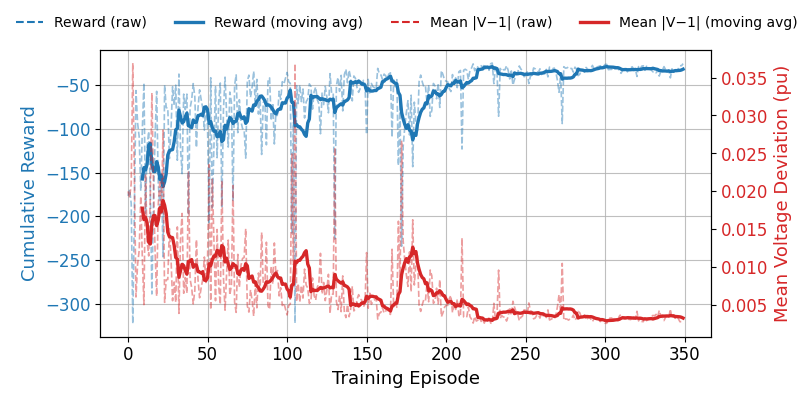

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def moving_average(x, w=10):
    return np.convolve(x, np.ones(w) / w, mode="valid")

episodes = np.arange(len(rl_logs["episode_reward"]))

fig, ax1 = plt.subplots(figsize=(8, 4))

# ---------------- Font sizes ----------------
LABEL_FONTSIZE = 13
TICK_FONTSIZE  = 12

# ---- Left axis: Reward ----
ax1.plot(
    episodes,
    rl_logs["episode_reward"],
    color="tab:blue",
    alpha=0.45,
    linestyle="--",
    linewidth=1.2
)
ax1.plot(
    episodes[9:],
    moving_average(rl_logs["episode_reward"], 10),
    color="tab:blue",
    linewidth=2.4
)
ax1.set_xlabel("Training Episode", fontsize=LABEL_FONTSIZE)
ax1.set_ylabel("Cumulative Reward", color="tab:blue", fontsize=LABEL_FONTSIZE)
ax1.tick_params(axis="x", labelsize=TICK_FONTSIZE)
ax1.tick_params(axis="y", labelsize=TICK_FONTSIZE, labelcolor="tab:blue")

# ---- Right axis: Voltage deviation ----
ax2 = ax1.twinx()
ax2.plot(
    episodes,
    rl_logs["episode_voltage_deviation"],
    color="tab:red",
    alpha=0.45,
    linestyle="--",
    linewidth=1.2
)
ax2.plot(
    episodes[9:],
    moving_average(rl_logs["episode_voltage_deviation"], 10),
    color="tab:red",
    linewidth=2.4
)
ax2.set_ylabel("Mean Voltage Deviation (pu)", color="tab:red", fontsize=LABEL_FONTSIZE)
ax2.tick_params(axis="y", labelsize=TICK_FONTSIZE, labelcolor="tab:red")

# ---- Custom Legend (clear + meaningful) ----
legend_lines = [
    Line2D([0], [0], color="tab:blue", linestyle="--", linewidth=1.5,
           label="Reward (raw)"),
    Line2D([0], [0], color="tab:blue", linestyle="-", linewidth=2.4,
           label="Reward (moving avg)"),
    Line2D([0], [0], color="tab:red", linestyle="--", linewidth=1.5,
           label="Mean |V−1| (raw)"),
    Line2D([0], [0], color="tab:red", linestyle="-", linewidth=2.4,
           label="Mean |V−1| (moving avg)")
]

fig.legend(
    handles=legend_lines,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1)
)

# ---- Styling ----
ax1.grid(True, alpha=0.8)
plt.tight_layout(rect=[0, 0, 1, 0.92])

# ---- Save as PDF ----
plt.savefig("RL_Training_Convergence.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [39]:
# Metrics
for name, s in [("PID", sim_pid), ("LSTM-baseline", sim_lstm), ("Proposed RL", sim_rl)]:
    m = compute_metrics(s, sim.I_max_pu, P3_KW_24, P4_KW_24)
    print("\n===", name, "===")
    for k,v in m.items():
        print(k, ":", v)



=== PID ===
max_vdev_pu : 0.011259266281552383
mean_vdev_pu : 0.002779878403387476
overI_events : 0
control_effort_mean : 1.7155663344779904e-05
control_effort_rms : 2.4888697354465012e-05
peak_hours : [16, 20]
recovery_5pct_hours : {16: 0.0, 20: 0.0}
recovery_1pct_hours : {16: 0.0, 20: 0.0}

=== LSTM-baseline ===
max_vdev_pu : 0.07934378205926318
mean_vdev_pu : 0.05407116769563709
overI_events : 0
control_effort_mean : 1.8501321342256364e-05
control_effort_rms : 0.0003392630988208164
peak_hours : [16, 20]
recovery_5pct_hours : {16: nan, 20: nan}
recovery_1pct_hours : {16: nan, 20: nan}

=== Proposed RL ===
max_vdev_pu : 0.012425766530387405
mean_vdev_pu : 0.0024203965234301833
overI_events : 0
control_effort_mean : 0.00046958333333328375
control_effort_rms : 0.0004926966612429489
peak_hours : [16, 20]
recovery_5pct_hours : {16: 0.0, 20: 0.0}
recovery_1pct_hours : {16: 0.0, 20: 0.0}


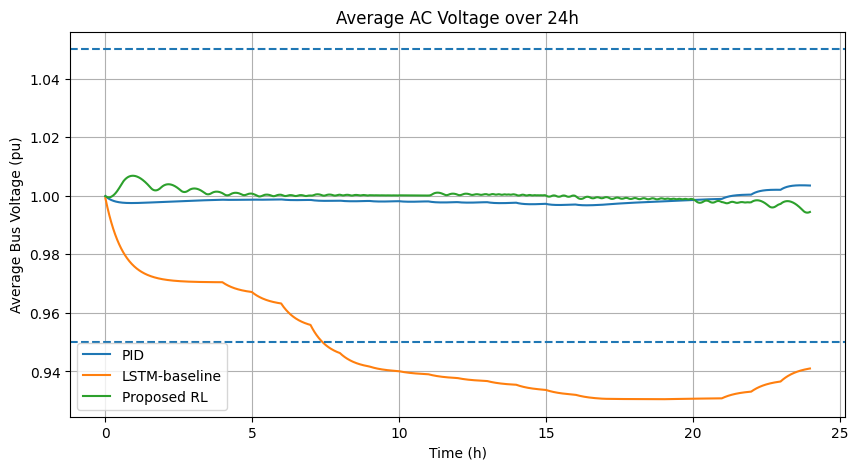

In [40]:
# Plot average voltage
plt.figure(figsize=(10,5))
plt.plot(sim_pid["t"], np.mean(sim_pid["V"], axis=1), label="PID")
plt.plot(sim_lstm["t"], np.mean(sim_lstm["V"], axis=1), label="LSTM-baseline")
plt.plot(sim_rl["t"], np.mean(sim_rl["V"], axis=1), label="Proposed RL")
plt.axhline(1.05, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Time (h)")
plt.ylabel("Average Bus Voltage (pu)")
plt.title("Average AC Voltage over 24h")
plt.legend()
plt.grid(True)
plt.show()


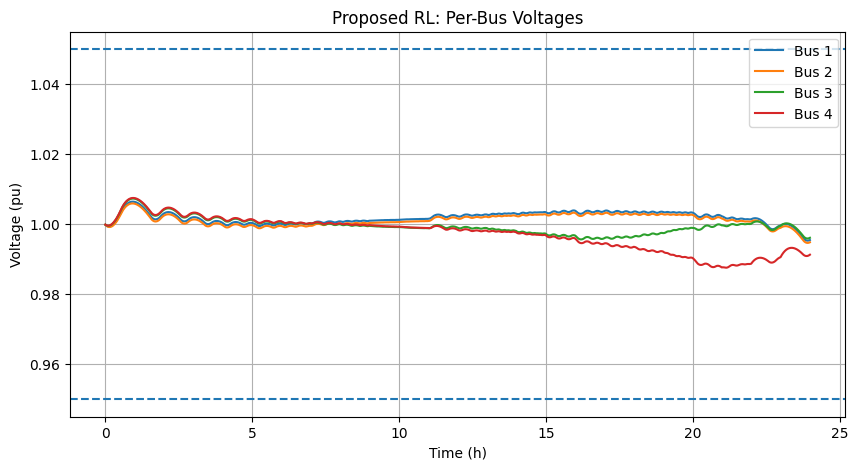

In [41]:
# Plot per-bus voltages for RL
plt.figure(figsize=(10,5))
for i in range(4):
    plt.plot(sim_rl["t"], sim_rl["V"][:, i], label=f"Bus {i+1}")
plt.axhline(1.05, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Time (h)")
plt.ylabel("Voltage (pu)")
plt.title("Proposed RL: Per-Bus Voltages")
plt.legend()
plt.grid(True)
plt.show()


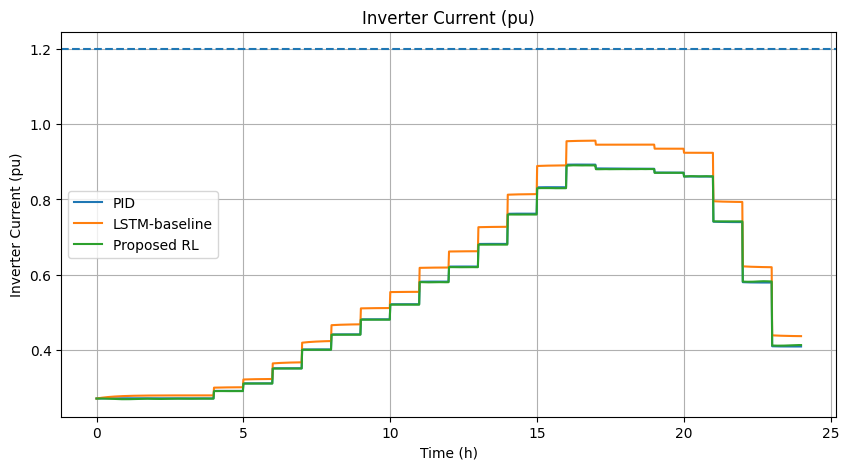

In [42]:
# Plot inverter current
plt.figure(figsize=(10,5))
plt.plot(sim_pid["t"], sim_pid["Iinv_pu"], label="PID")
plt.plot(sim_lstm["t"], sim_lstm["Iinv_pu"], label="LSTM-baseline")
plt.plot(sim_rl["t"], sim_rl["Iinv_pu"], label="Proposed RL")
plt.axhline(sim.I_max_pu, linestyle="--")
plt.xlabel("Time (h)")
plt.ylabel("Inverter Current (pu)")
plt.title("Inverter Current (pu)")
plt.legend()
plt.grid(True)
plt.show()


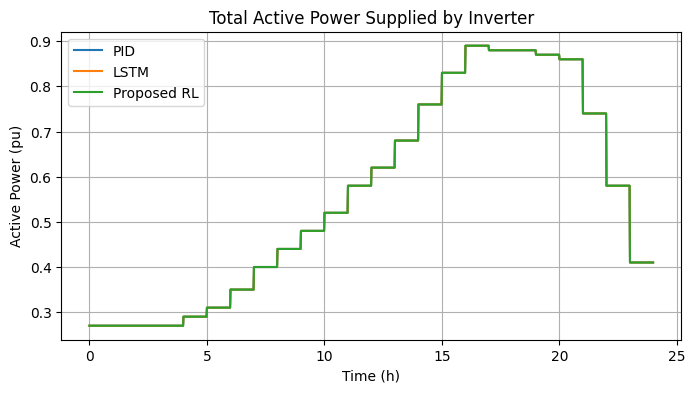

In [44]:
plt.figure(figsize=(8,4))
plt.plot(sim_pid["t"], sim_pid["P_total_pu"], label="PID")
plt.plot(sim_lstm["t"], sim_lstm["P_total_pu"], label="LSTM")
plt.plot(sim_rl["t"], sim_rl["P_total_pu"], label="Proposed RL")
plt.xlabel("Time (h)")
plt.ylabel("Active Power (pu)")
plt.title("Total Active Power Supplied by Inverter")
plt.legend()
plt.grid(True)
plt.show()


In [46]:
import pandas as pd

metrics_table = pd.DataFrame({
    "PID": compute_metrics(sim_pid, sim.I_max_pu, P3_KW_24, P4_KW_24),
    "LSTM": compute_metrics(sim_lstm, sim.I_max_pu, P3_KW_24, P4_KW_24),
    "Proposed RL": compute_metrics(sim_rl, sim.I_max_pu, P3_KW_24, P4_KW_24),
})

metrics_table


,PID,LSTM,Proposed RL
max_vdev_pu,0.011259,0.079344,0.012426
mean_vdev_pu,0.00278,0.054071,0.00242
overI_events,0,0,0
control_effort_mean,0.000017,0.000019,0.00047
control_effort_rms,0.000025,0.000339,0.000493
peak_hours,"[16, 20]","[16, 20]","[16, 20]"
recovery_5pct_hours,"{16: 0.0, 20: 0.0}","{16: nan, 20: nan}","{16: 0.0, 20: 0.0}"
recovery_1pct_hours,"{16: 0.0, 20: 0.0}","{16: nan, 20: nan}","{16: 0.0, 20: 0.0}"


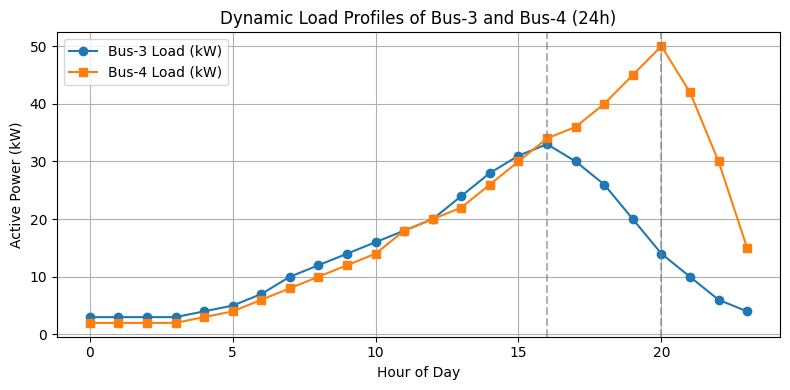

In [47]:
# ===== 24h Load Profiles (Bus-3 & Bus-4) =====
hours = np.arange(24)

plt.figure(figsize=(8,4))
plt.plot(hours, P3_KW_24, marker='o', label="Bus-3 Load (kW)")
plt.plot(hours, P4_KW_24, marker='s', label="Bus-4 Load (kW)")
plt.axvline(16, linestyle="--", color="gray", alpha=0.6)
plt.axvline(20, linestyle="--", color="gray", alpha=0.6)
plt.xlabel("Hour of Day")
plt.ylabel("Active Power (kW)")
plt.title("Dynamic Load Profiles of Bus-3 and Bus-4 (24h)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


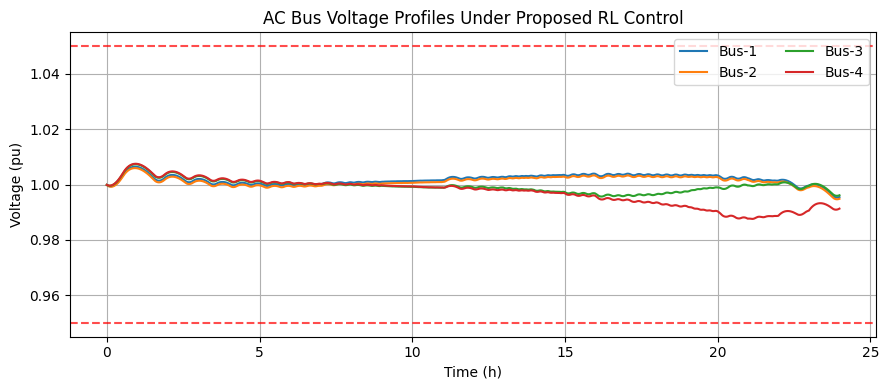

In [49]:
# ===== AC Bus Voltages (Proposed RL) =====
plt.figure(figsize=(9,4))

for i in range(4):
    plt.plot(sim_rl["t"], sim_rl["V"][:, i],
             label=f"Bus-{i+1}")

plt.axhline(1.05, linestyle="--", color="red", alpha=0.7)
plt.axhline(0.95, linestyle="--", color="red", alpha=0.7)

plt.xlabel("Time (h)")
plt.ylabel("Voltage (pu)")
plt.title("AC Bus Voltage Profiles Under Proposed RL Control")
plt.legend(ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()


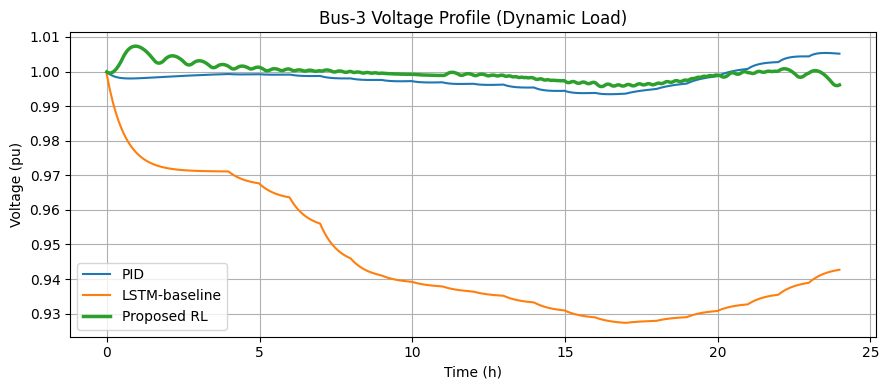

In [50]:
# ===== Bus-3 Voltage Comparison =====
plt.figure(figsize=(9,4))

plt.plot(sim_pid["t"], sim_pid["V"][:, 2], label="PID")
plt.plot(sim_lstm["t"], sim_lstm["V"][:, 2], label="LSTM-baseline")
plt.plot(sim_rl["t"], sim_rl["V"][:, 2], label="Proposed RL", linewidth=2.5)

#plt.axhline(1.05, linestyle="--", color="red", alpha=0.7)
#plt.axhline(0.95, linestyle="--", color="red", alpha=0.7)

plt.xlabel("Time (h)")
plt.ylabel("Voltage (pu)")
plt.title("Bus-3 Voltage Profile (Dynamic Load)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


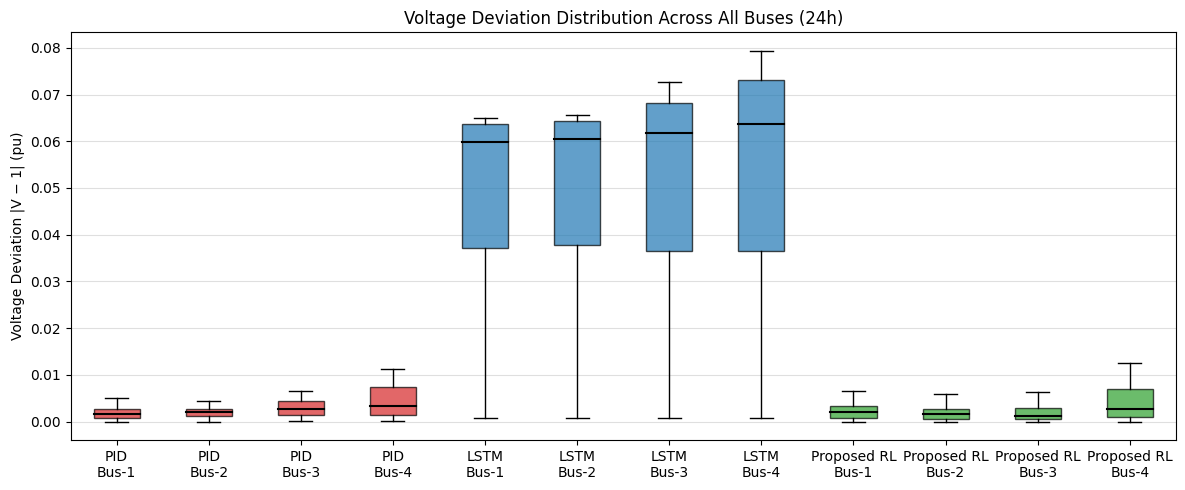

In [51]:
# ===== Boxplot: Voltage Deviation (All Buses × Controllers) =====

# Voltage deviation per bus
def vdev(sim, bus_idx):
    return np.abs(sim["V"][:, bus_idx] - 1.0)

data = []
labels = []

controllers = [
    ("PID", sim_pid),
    ("LSTM", sim_lstm),
    ("Proposed RL", sim_rl),
]

for name, sim in controllers:
    for b in range(4):
        data.append(vdev(sim, b))
        labels.append(f"{name}\nBus-{b+1}")

plt.figure(figsize=(12,5))

bp = plt.boxplot(
    data,
    labels=labels,
    showfliers=False,
    patch_artist=True
)

# Coloring by controller (optional but very nice)
colors = ["#d62728", "#1f77b4", "#2ca02c"]  # PID, LSTM, RL
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors[i // 4])
    patch.set_alpha(0.7)

# Make medians black
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

plt.ylabel("Voltage Deviation |V − 1| (pu)")
plt.title("Voltage Deviation Distribution Across All Buses (24h)")
plt.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


In [57]:
import numpy as np
import matplotlib.pyplot as plt

sim_pid  = dict(np.load("results/sim_pid.npz"))
sim_lstm = dict(np.load("results/sim_lstm.npz"))
sim_rl   = dict(np.load("results/sim_rl.npz"))
